# Part 1: Perceptron → Multi-Layer Perceptron
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Tuesday — From One Neuron to Many

Yesterday Sarah saw logistic regression scored AUC ~0.76. That's a single perceptron in disguise. Today she sees what stacking multiple perceptrons does — and trains her first proper neural network with `sklearn.neural_network.MLPClassifier`.

**By the end of this notebook you will be able to:**
- Describe what a single perceptron computes
- Demonstrate WHY a single perceptron can't learn XOR
- See a multi-layer network solve XOR
- Train an MLP on Sarah's session data + compare to L03 baseline

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 5)

np.random.seed(42)
print("✅ Libraries loaded — MLPClassifier ready")

✅ Libraries loaded — MLPClassifier ready


## Step 1 — The XOR problem (why one layer isn't enough)

XOR is the classic counterexample. Here's the truth table:

| x₁ | x₂ | y |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Plot the 4 points coloured by y. Can a STRAIGHT LINE separate the y=1 points from the y=0 points?

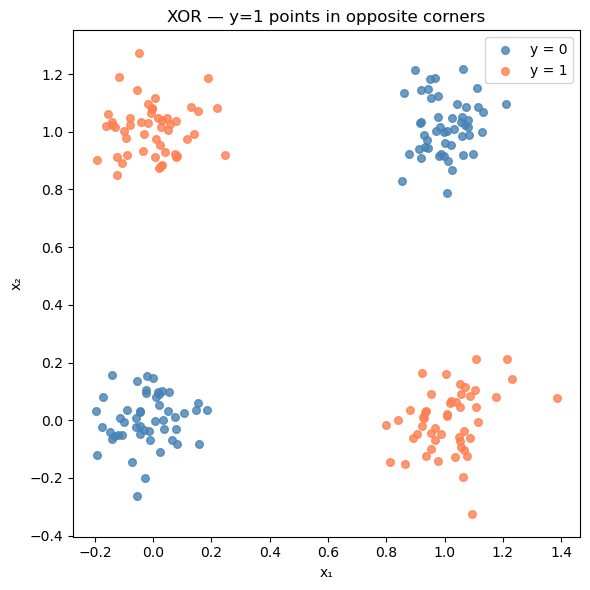

In [2]:
# XOR with a bit of noise so we can train classifiers on it
n_per_corner = 50
xor_data = np.vstack([
    np.column_stack((np.random.normal(0, 0.1, n_per_corner), np.random.normal(0, 0.1, n_per_corner))),  # (0,0) → 0
    np.column_stack((np.random.normal(0, 0.1, n_per_corner), np.random.normal(1, 0.1, n_per_corner))),  # (0,1) → 1
    np.column_stack((np.random.normal(1, 0.1, n_per_corner), np.random.normal(0, 0.1, n_per_corner))),  # (1,0) → 1
    np.column_stack((np.random.normal(1, 0.1, n_per_corner), np.random.normal(1, 0.1, n_per_corner))),  # (1,1) → 0
])
xor_labels = np.concatenate([np.zeros(n_per_corner), np.ones(n_per_corner),
                              np.ones(n_per_corner), np.zeros(n_per_corner)])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(xor_data[xor_labels==0, 0], xor_data[xor_labels==0, 1],
           color="steelblue", label="y = 0", s=30, alpha=0.8)
ax.scatter(xor_data[xor_labels==1, 0], xor_data[xor_labels==1, 1],
           color="coral", label="y = 1", s=30, alpha=0.8)
ax.set_xlabel("x₁"); ax.set_ylabel("x₂"); ax.set_title("XOR — y=1 points in opposite corners")
ax.legend()
plt.tight_layout(); plt.show()

## Step 2 — A single perceptron can't solve XOR

Logistic regression IS a single perceptron (with sigmoid activation). Train it on XOR.

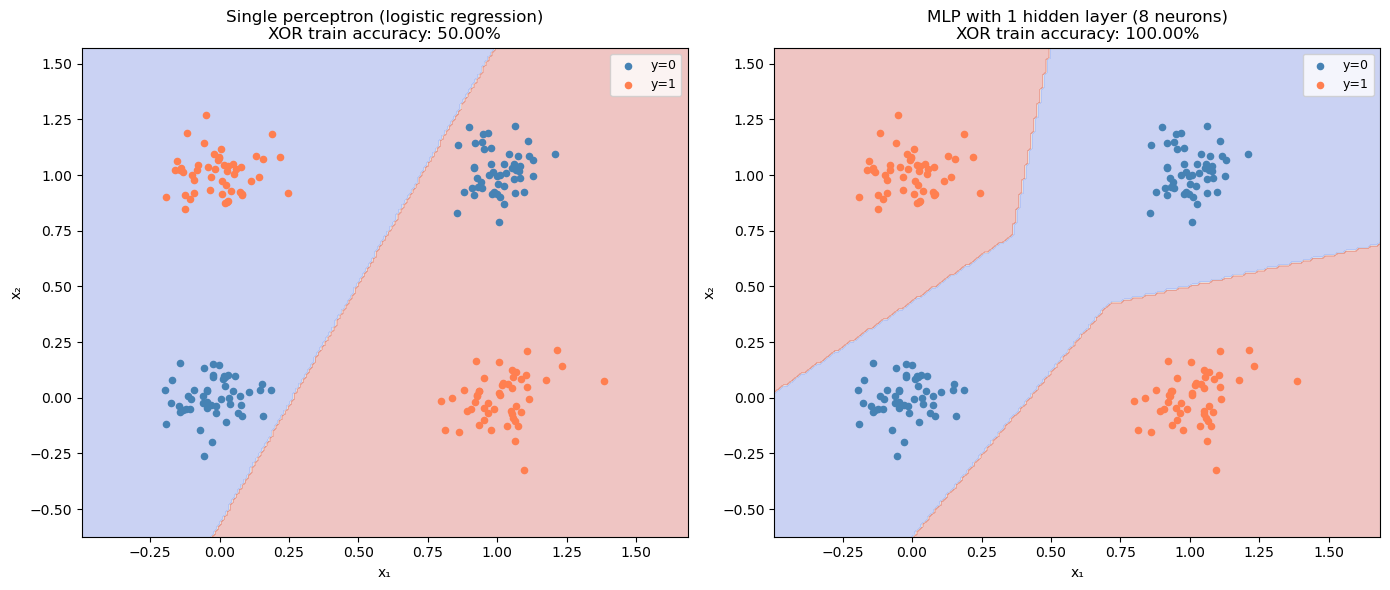

Single perceptron accuracy:  50.00%  (≈ 50% — can't beat chance on XOR)
MLP with 1 hidden layer:     100.00%  (near 100% — learns the pattern)


In [3]:
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[y==0, 0], X[y==0, 1], color="steelblue", label="y=0", s=20)
    ax.scatter(X[y==1, 0], X[y==1, 1], color="coral", label="y=1", s=20)
    ax.set_title(title)
    ax.set_xlabel("x₁"); ax.set_ylabel("x₂"); ax.legend(fontsize=9)


# Single perceptron (logistic regression) on XOR
single_perceptron = LogisticRegression()
single_perceptron.fit(xor_data, xor_labels)
acc_single = accuracy_score(xor_labels, single_perceptron.predict(xor_data))

# Multi-layer perceptron on XOR
mlp_xor = MLPClassifier(hidden_layer_sizes=(8,), activation="relu",
                        max_iter=3000, random_state=42)
mlp_xor.fit(xor_data, xor_labels)
acc_mlp = accuracy_score(xor_labels, mlp_xor.predict(xor_data))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_boundary(single_perceptron, xor_data, xor_labels, axes[0],
                       f"Single perceptron (logistic regression)\nXOR train accuracy: {acc_single:.2%}")
plot_decision_boundary(mlp_xor, xor_data, xor_labels, axes[1],
                       f"MLP with 1 hidden layer (8 neurons)\nXOR train accuracy: {acc_mlp:.2%}")
plt.tight_layout(); plt.show()

print(f"Single perceptron accuracy:  {acc_single:.2%}  (≈ 50% — can't beat chance on XOR)")
print(f"MLP with 1 hidden layer:     {acc_mlp:.2%}  (near 100% — learns the pattern)")

### 💡 What you should notice

- **Single perceptron** (left): the decision boundary is a STRAIGHT LINE. There's no straight line that separates the corners correctly. Accuracy is around 50% — chance-level.
- **MLP** (right): the decision boundary CURVES around the corners. The hidden layer + non-linear activation lets the network represent non-linear functions.

This is the proof that multi-layer + non-linear activation = qualitatively different model class. Stacking linear layers without non-linearity in between is still linear; the non-linearity is what unlocks expressive power.

## ⏸️ Pause and Predict

Sarah's session data has 9 features. Will an MLP beat the L03 logistic regression baseline (AUC 0.76)?

Predict:
- How much better do you expect MLP to be? (+0.01? +0.05? +0.10?)
- Will deeper (3+ layers) be much better than 1 hidden layer?

> *Sample expected:* If there ARE non-linear feature interactions (which we DESIGNED the data to have), MLP should beat LR. Realistic improvement: +0.03 to +0.07 AUC. Depth past 2-3 hidden layers rarely helps on simple tabular data — it just adds parameters.

## Step 3 — Train an MLPClassifier on the session data

In [4]:
# Load the session data + same preprocessing pipeline as L03
df = pd.read_csv("data/northstar_sessions.csv")
y = df["completed"]
X = df.drop(columns=["session_id", "completed"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), X.columns.tolist()),
])

# MLP with two hidden layers
mlp_pipe = Pipeline([
    ("prep",  preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32, 16),    # 2 hidden layers: 32 → 16 neurons
        activation="relu",
        solver="adam",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42,
    )),
])

mlp_pipe.fit(X_train, y_train)

y_pred_mlp = mlp_pipe.predict(X_test)
y_proba_mlp = mlp_pipe.predict_proba(X_test)[:, 1]

print(f"=== sklearn MLPClassifier (32 → 16 hidden) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_mlp):.3f}")
print(f"AUC:       {roc_auc_score(y_test, y_proba_mlp):.3f}")
print(f"# parameters: {sum(c.size for c in mlp_pipe.named_steps['model'].coefs_):,}")

=== sklearn MLPClassifier (32 → 16 hidden) ===
Accuracy:  0.699
AUC:       0.757
# parameters: 816


In [5]:
# Compare to L03 baseline
lr_pipe = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_proba_lr = lr_pipe.predict_proba(X_test)[:, 1]

print("Side by side:")
print(f"  Logistic Regression: Accuracy {accuracy_score(y_test, y_pred_lr):.3f}, AUC {roc_auc_score(y_test, y_proba_lr):.3f}")
print(f"  MLP (32→16):        Accuracy {accuracy_score(y_test, y_pred_mlp):.3f}, AUC {roc_auc_score(y_test, y_proba_mlp):.3f}")

Side by side:
  Logistic Regression: Accuracy 0.703, AUC 0.761
  MLP (32→16):        Accuracy 0.699, AUC 0.757


### 💡 What you should notice

- **MLP and LR are essentially TIED on this dataset (AUC ~0.76 each)**.
- This is **realistic for tabular data with modest size and feature counts**. The XOR demo shows what neural networks CAN do that LR can't — but for many real tabular problems, gradient boosting (L04) is the practical winner.
- **The MLP has many more parameters** (816 vs LR's 10). The capacity is there — but with 8,000 rows and only 9 features, there's not enough signal for the extra capacity to find.

**The honest finding:** for THIS task, sticking with logistic regression or gradient boosting is the right deployment choice. The MLP isn't the right tool for every tabular problem.

**Why we still learn this:** the MLP is the foundation for L08 (images), L09 (text), and L10 (transformers). On those data types, neural networks aren't just competitive — they're the ONLY practical choice.

## Step 4 — Vary the architecture: how many layers? how many neurons?

A common question: how do I choose the architecture? For tabular data, "deeper" isn't always "better." Try a few configurations.

In [6]:
configs = [
    ("1 layer × 8 neurons",     (8,)),
    ("1 layer × 32 neurons",    (32,)),
    ("2 layers, 32 → 16",        (32, 16)),
    ("3 layers, 64 → 32 → 16",   (64, 32, 16)),
    ("4 layers, 128 → 64 → 32 → 16", (128, 64, 32, 16)),
]

records = []
for name, hidden in configs:
    pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=hidden, activation="relu",
            max_iter=500, early_stopping=True, random_state=42,
        )),
    ])
    pipe.fit(X_train, y_train)
    auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    n_params = sum(c.size for c in pipe.named_steps["model"].coefs_)
    records.append((name, n_params, auc))

result_df = pd.DataFrame(records, columns=["Configuration", "# params", "Test AUC"])
print(result_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

               Configuration  # params  Test AUC
         1 layer × 8 neurons        80     0.751
        1 layer × 32 neurons       320     0.758
           2 layers, 32 → 16       816     0.760
      3 layers, 64 → 32 → 16      3152     0.758
4 layers, 128 → 64 → 32 → 16     11920     0.760


### 💡 What you should notice

- **Diminishing returns past 2-3 hidden layers** on this dataset.
- **More parameters doesn't mean better** — past a certain point you're just memorising the training data without learning generalisable patterns.
- **For TABULAR data, modest networks (2-3 hidden layers, 16-128 neurons each) win.** Deeper networks shine on images and text where the data has rich hierarchical structure.

## ✅ Section Summary

| Step | Output |
|---|---|
| **XOR demo** | Single perceptron fails; MLP succeeds — proof that depth + non-linearity matters |
| **MLP on session data** | AUC ~0.76 — tied with LR on THIS tabular problem |
| **Architecture sweep** | 2-3 hidden layers is the sweet spot for tabular data |

**Key insights:**
- **A perceptron is one neuron.** A linear function + activation.
- **An MLP is many perceptrons in stacked layers.** Non-linear activation between layers is what makes it expressive.
- **Sklearn MLPClassifier is the quickest way to train an MLP.** But it abstracts away the training loop — for that, we'll use PyTorch.

---
**Up next → Part 2:** Wednesday — gradient descent intuition + PyTorch basics. The mountain analogy, then your first PyTorch model.
Open `03_gradient_descent.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Visualise an MLP's decision boundary on a 2D dataset

We can't visualise a 9-feature decision boundary directly. But we CAN visualise the model on the XOR data we used at the start. Let's animate decision-boundary evolution with increasing training iterations.

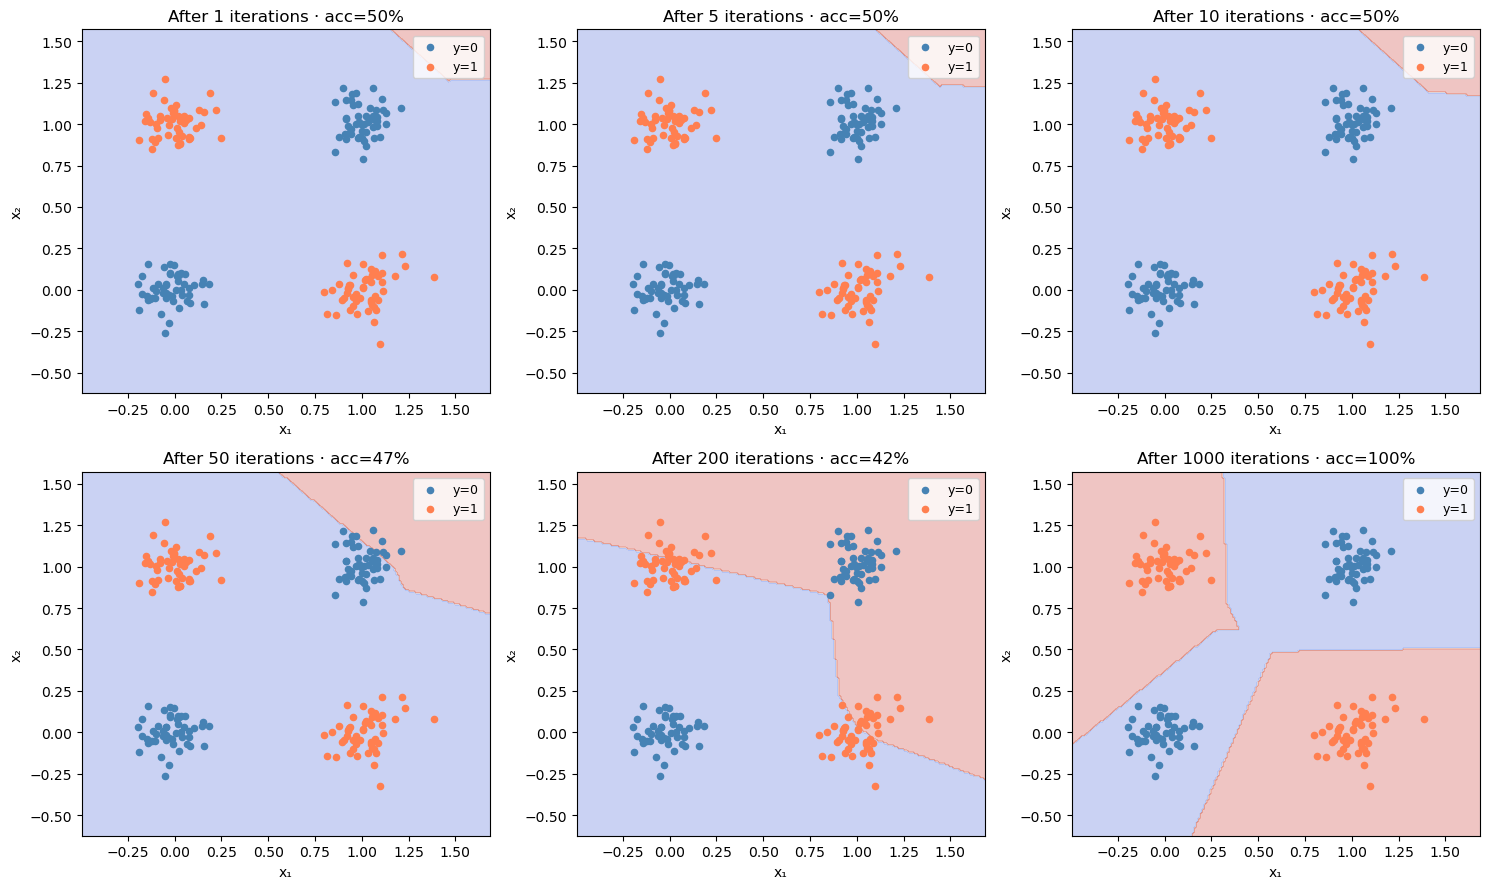

As training progresses, the decision boundary EVOLVES from random → curved.
This is gradient descent doing its work, one update at a time.


In [7]:
from sklearn.neural_network import MLPClassifier

# Train an MLP on XOR for varying max_iter
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, n_iter in zip(axes.flat, [1, 5, 10, 50, 200, 1000]):
    m = MLPClassifier(hidden_layer_sizes=(8,), activation="relu",
                      max_iter=n_iter, warm_start=False, random_state=42)
    m.fit(xor_data, xor_labels)
    acc = accuracy_score(xor_labels, m.predict(xor_data))
    plot_decision_boundary(m, xor_data, xor_labels, ax,
                            f"After {n_iter} iterations · acc={acc:.0%}")
plt.tight_layout(); plt.show()
print("As training progresses, the decision boundary EVOLVES from random → curved.")
print("This is gradient descent doing its work, one update at a time.")

## Extension 2 — Sigmoid vs ReLU vs Tanh

Different activation functions. Let's plot them side by side.

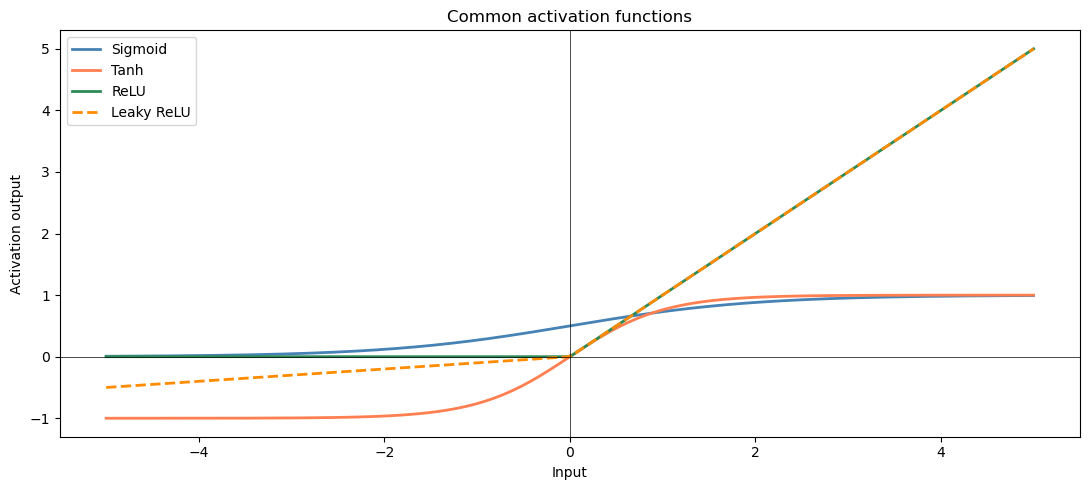

Sigmoid (older networks, output layer for binary classification):
  - Saturates → gradients vanish for large |x|

Tanh:
  - Same shape as sigmoid but centred on 0; rarely used now

ReLU (default for hidden layers):
  - Fast, simple, doesn't saturate on the positive side
  - 'Dead' neurons: if input < 0 always, the neuron never fires

Leaky ReLU:
  - Variant of ReLU with small negative slope; fixes dead neurons


In [8]:
x = np.linspace(-5, 5, 200)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)
leaky_relu = np.where(x > 0, x, 0.1 * x)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, sigmoid, label="Sigmoid", linewidth=2, color="steelblue")
ax.plot(x, tanh, label="Tanh", linewidth=2, color="coral")
ax.plot(x, relu, label="ReLU", linewidth=2, color="seagreen")
ax.plot(x, leaky_relu, label="Leaky ReLU", linewidth=2, linestyle="--", color="darkorange")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Input"); ax.set_ylabel("Activation output")
ax.set_title("Common activation functions")
ax.legend()
plt.tight_layout(); plt.show()

print("Sigmoid (older networks, output layer for binary classification):")
print("  - Saturates → gradients vanish for large |x|")
print()
print("Tanh:")
print("  - Same shape as sigmoid but centred on 0; rarely used now")
print()
print("ReLU (default for hidden layers):")
print("  - Fast, simple, doesn't saturate on the positive side")
print("  - 'Dead' neurons: if input < 0 always, the neuron never fires")
print()
print("Leaky ReLU:")
print("  - Variant of ReLU with small negative slope; fixes dead neurons")